In [10]:
import pandas as pd

In [11]:
df = pd.read_csv("C:/Users/nikhi/OneDrive/Desktop/Product_analyst_project/data/processed/2019-Dec_cleaned.csv")

In [27]:
df.shape

(3348712, 9)

In [12]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-12-01 00:00:00+00:00,remove_from_cart,5712790,1487580005268456287,unknown,f.o.x,6.27,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc
1,2019-12-01 00:00:00+00:00,view,5764655,1487580005411062629,unknown,cnd,29.05,412120092,8adff31e-2051-4894-9758-224bfa8aec18
2,2019-12-01 00:00:02+00:00,cart,4958,1487580009471148064,unknown,runail,1.19,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554
3,2019-12-01 00:00:05+00:00,view,5848413,1487580007675986893,unknown,freedecor,0.79,348405118,722ffea5-73c0-4924-8e8f-371ff8031af4
4,2019-12-01 00:00:07+00:00,view,5824148,1487580005511725929,unknown,unknown,5.56,576005683,28172809-7e4a-45ce-bab0-5efa90117cd5


In [13]:
df["event_type"].value_counts()

event_type
view                1728216
cart                 911048
remove_from_cart     496382
purchase             213066
Name: count, dtype: int64

In [14]:
df.groupby("event_type")["user_id"].nunique()

event_type
cart                 83311
purchase             25613
remove_from_cart     45179
view                358208
Name: user_id, dtype: int64

In [17]:
view_users = 358208
cart_users = 83311
purchases = 25613

In [18]:
conversionrate_to_cart = cart_users/view_users*100

In [19]:
conversionrate_to_cart

23.257716187243165

In [20]:
conversion_rate_to_purchase = purchases/cart_users*100

In [21]:
conversion_rate_to_purchase

30.743839348945517

In [22]:
#top10 categories of purchases
df[df["event_type"]=="purchase"].groupby("category_code").size().sort_values(ascending=False).head(10)

category_code
unknown                                   210364
stationery.cartrige                          980
apparel.glove                                771
appliances.environment.vacuum                636
furniture.bathroom.bath                      183
accessories.bag                               42
furniture.living_room.cabinet                 40
accessories.cosmetic_bag                      34
appliances.personal.hair_cutter               14
appliances.environment.air_conditioner         2
dtype: int64

In [23]:
#Top 10 categories by views
df[df["event_type"]=="view"].groupby("category_code").size().sort_values(ascending=False).head(10)

category_code
unknown                                   1689474
appliances.environment.vacuum               20184
accessories.bag                              4538
furniture.living_room.cabinet                3760
apparel.glove                                3324
stationery.cartrige                          3283
furniture.bathroom.bath                      2155
appliances.personal.hair_cutter               923
accessories.cosmetic_bag                      481
appliances.environment.air_conditioner         74
dtype: int64

In [24]:
#categories by views
category_views = df[df["event_type"]=="view"].groupby("category_code").size()

In [25]:
category_views

category_code
accessories.bag                              4538
accessories.cosmetic_bag                      481
apparel.glove                                3324
appliances.environment.air_conditioner         74
appliances.environment.vacuum               20184
appliances.personal.hair_cutter               923
furniture.bathroom.bath                      2155
furniture.living_room.cabinet                3760
furniture.living_room.chair                    20
stationery.cartrige                          3283
unknown                                   1689474
dtype: int64

In [26]:
#categories of purchases
category_purchase = df[df["event_type"]=="purchase"].groupby("category_code").size()

In [27]:
category_purchase

category_code
accessories.bag                               42
accessories.cosmetic_bag                      34
apparel.glove                                771
appliances.environment.air_conditioner         2
appliances.environment.vacuum                636
appliances.personal.hair_cutter               14
furniture.bathroom.bath                      183
furniture.living_room.cabinet                 40
stationery.cartrige                          980
unknown                                   210364
dtype: int64

In [28]:
conversion_rate_ = category_purchase/category_views*100

In [29]:
conversion_rate_.sort_values(ascending=False)

category_code
stationery.cartrige                       29.850746
apparel.glove                             23.194946
unknown                                   12.451449
furniture.bathroom.bath                    8.491879
accessories.cosmetic_bag                   7.068607
appliances.environment.vacuum              3.151011
appliances.environment.air_conditioner     2.702703
appliances.personal.hair_cutter            1.516793
furniture.living_room.cabinet              1.063830
accessories.bag                            0.925518
furniture.living_room.chair                     NaN
dtype: float64

In [30]:
#Unique users who added to cart
unique_cart_users = df[df["event_type"]=="cart"]["user_id"].nunique()

In [31]:
unique_cart_users

83311

In [32]:
#Unique users who purchased
unique_purchase_user = df[df["event_type"]=="purchase"]["user_id"].nunique()

In [154]:
unique_purchase_user

25613

In [33]:
#Unique users who removed from cart
unique_user_remove_cart = df[df["event_type"]=="remove_from_cart"]["user_id"].nunique()

In [34]:
unique_user_remove_cart


45179

In [35]:
#Cart → Purchase Conversion
unique_purchase_user/unique_cart_users*100

30.743839348945517

In [36]:
#Remove From Cart Rate
unique_user_remove_cart/unique_cart_users*100

54.229333461367645

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3348712 entries, 0 to 3348711
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 229.9+ MB


In [38]:
df["event_time"]=pd.to_datetime(df["event_time"])

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3348712 entries, 0 to 3348711
Data columns (total 9 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[ns, UTC]
 1   event_type     object             
 2   product_id     int64              
 3   category_id    int64              
 4   category_code  object             
 5   brand          object             
 6   price          float64            
 7   user_id        int64              
 8   user_session   object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(3), object(4)
memory usage: 229.9+ MB


In [40]:
df["hour"]=df["event_time"].dt.hour

In [41]:
df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,hour
0,2019-12-01 00:00:00+00:00,remove_from_cart,5712790,1487580005268456287,unknown,f.o.x,6.27,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc,0
1,2019-12-01 00:00:00+00:00,view,5764655,1487580005411062629,unknown,cnd,29.05,412120092,8adff31e-2051-4894-9758-224bfa8aec18,0
2,2019-12-01 00:00:02+00:00,cart,4958,1487580009471148064,unknown,runail,1.19,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554,0
3,2019-12-01 00:00:05+00:00,view,5848413,1487580007675986893,unknown,freedecor,0.79,348405118,722ffea5-73c0-4924-8e8f-371ff8031af4,0
4,2019-12-01 00:00:07+00:00,view,5824148,1487580005511725929,unknown,unknown,5.56,576005683,28172809-7e4a-45ce-bab0-5efa90117cd5,0
...,...,...,...,...,...,...,...,...,...,...
3348707,2019-12-31 23:59:39+00:00,view,5683350,1487580005671109489,unknown,masura,2.84,536812729,e4a2d47c-a956-4c46-8176-745f52ea664b,23
3348708,2019-12-31 23:59:46+00:00,view,5888097,1487580013388628160,unknown,shik,179.05,503658154,2dde9867-9e71-4a64-880d-aa68b66aae6d,23
3348709,2019-12-31 23:59:51+00:00,view,59975,1487580012096782476,unknown,unknown,7.14,595414541,4c6d80bb-5dd3-4fbb-b592-187b51db2753,23
3348710,2019-12-31 23:59:52+00:00,view,5775982,1783999063314661546,unknown,unknown,11.90,397780878,7e8a2b85-153a-44eb-a71f-b748fde14fcc,23


In [42]:
purchase_by_hour = df[df["event_type"]=="purchase"].groupby("hour").size().sort_values(ascending=False)

In [43]:
purchase_by_hour

hour
11    14836
10    13884
12    13133
9     12640
13    12451
20    12262
14    11988
8     11877
18    11699
19    11623
17    11044
7     10861
15    10576
16    10402
21     8889
6      8491
5      6066
22     5805
4      3320
23     2844
3      2734
0      1999
2      1994
1      1648
dtype: int64

In [44]:
import matplotlib.pyplot as plt

stages = ["views","cart","purchases"]
values = [358208,83311,25613]

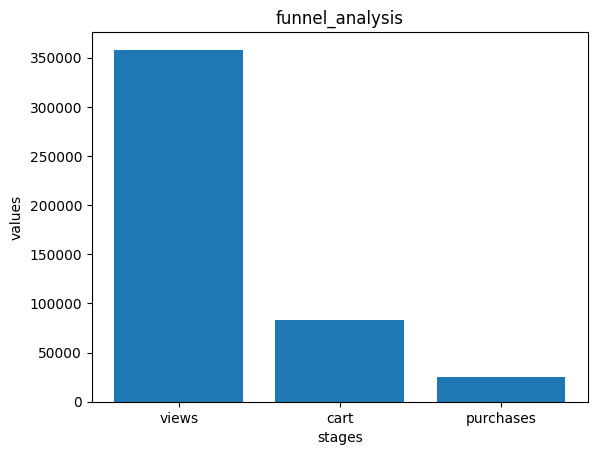

In [45]:
plt.figure()
plt.bar(stages,values)
plt.title('funnel_analysis')
plt.xlabel("stages")
plt.ylabel("values")
plt.show()

In [46]:
#top10 conversion categories
sorted_conversion  = conversion_rate_.sort_values(ascending=False).head(10)

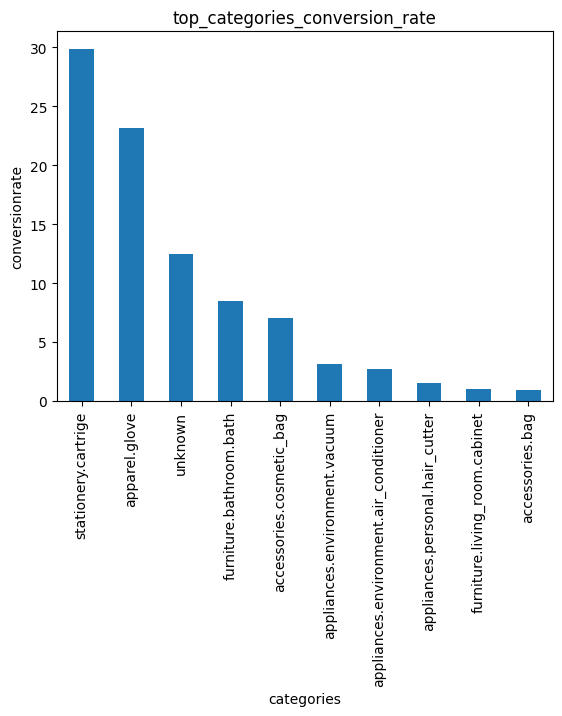

In [47]:
plt.figure()
sorted_conversion.plot(kind="bar")
plt.title("top_categories_conversion_rate")
plt.xlabel("categories")
plt.ylabel("conversionrate")
plt.show()

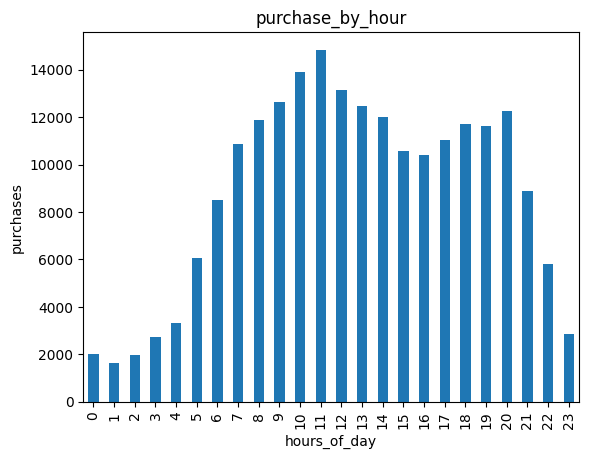

In [48]:
#purchase_by_hour
plt.figure()
purchase_by_hour.sort_index().plot(kind="bar")
plt.title("purchase_by_hour")
plt.xlabel("hours_of_day")
plt.ylabel("purchases")
plt.show()

In [58]:
#userbehaviours
user_behavior =df.groupby(["user_id","event_type"]).size().unstack(fill_value=0)

In [50]:
user_behavior

event_type,cart,purchase,remove_from_cart,view
user_id,,,,
1180452,0,0,0,1
2963072,7,0,0,17
4661182,2,0,2,3
4891613,0,0,0,1
6217356,0,0,0,1
...,...,...,...,...
595413843,0,0,0,1
595413976,0,0,0,1
595414210,0,0,0,1


In [ ]:
buyers = user_behavior[user_behavior["purchase"]>0] 

In [54]:
len(buyers)

25613

In [60]:
#cart_abondoners

cart_abondoners = user_behavior[(user_behavior["cart"]>0) & (user_behavior["purchase"]==0)]

In [61]:
len(cart_abondoners)

58032

In [62]:
#users_who_never_added_to_cart
browsers = user_behavior[(user_behavior["view"]>0)& (user_behavior["cart"]==0)]

In [63]:
len(browsers)

285952

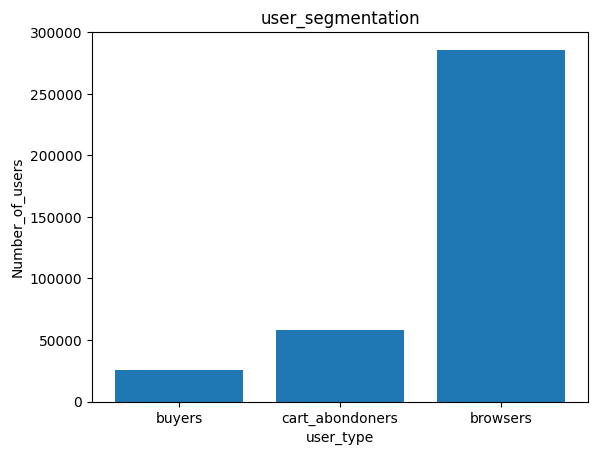

In [ ]:
#visualising_user_segment
segments = {"buyers":len(buyers),"cart_abondoners":len(cart_abondoners),"browsers":len(browsers)}
plt.bar(segments.keys(),segments.values())
plt.title("user_segmentation")
plt.xlabel("user_type")
plt.ylabel("Number_of_users")
plt.show()